In [9]:
import math
import torch
from torch.utils.data import TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1)
print(device)

cuda


In [ ]:
domain = {
    "S0":    (80.0, 120.0),
    "Y0":    (0.01, 0.35),
    "kappa": (0.5, 5.0),
    "mu":    (0.01, 0.25),
    "sigma": (0.1, 1.0),
    "r":     (0.00, 0.10) ,
    "rho":   (-0.95, 0.0),
    "K":     (60.0, 140.0),
    "T":     (0.1, 2.0),
}
feature_names = ["S0", "Y0", "kappa", "mu", "sigma", "r", "rho", "K", "T"]

In [11]:
# Sampling x with Feller rejection
def sample_uniform(n, low, high, device=device):
    return low + (high - low) * torch.rand(n, device=device)

def sample_heston_inputs(n_samples, domain=domain, enforce_feller=True, device=device):
    """
    Returns X of shape (n_samples, 9)
    columns = [S0, Y0, kappa, mu, sigma, r, rho, K, T]
    """
    xs = []

    n_collected = 0
    batch_size = max(2 * n_samples, 10000)

    while n_collected < n_samples:
        S0    = sample_uniform(batch_size, *domain["S0"], device=device)
        Y0    = sample_uniform(batch_size, *domain["Y0"], device=device)
        kappa = sample_uniform(batch_size, *domain["kappa"], device=device)
        mu    = sample_uniform(batch_size, *domain["mu"], device=device)
        sigma = sample_uniform(batch_size, *domain["sigma"], device=device)
        r     = sample_uniform(batch_size, *domain["r"], device=device)
        rho   = sample_uniform(batch_size, *domain["rho"], device=device)
        K     = sample_uniform(batch_size, *domain["K"], device=device)
        T     = sample_uniform(batch_size, *domain["T"], device=device)

        X_batch = torch.stack([S0, Y0, kappa, mu, sigma, r, rho, K, T], dim=1)

        if enforce_feller:
            # 2*kappa*mu > sigma^2
            mask = 2.0 * kappa * mu > sigma ** 2
            X_batch = X_batch[mask]

        xs.append(X_batch)
        n_collected += X_batch.shape[0]

    X = torch.cat(xs, dim=0)[:n_samples]
    return X

In [ ]:
# Heston Monte Carlo pricer
@torch.no_grad()
def heston_mc_price_batch(
    X,
    n_paths=20000,
    n_steps=100,
    device=device,
    dtype=torch.float32
):
    """
    Prices a batch of Heston European calls.
    """
    X = X.to(device=device, dtype=dtype)

    S0    = X[:, 0]
    Y0    = X[:, 1]
    kappa = X[:, 2]
    mu    = X[:, 3]
    sigma = X[:, 4]
    r     = X[:, 5]
    rho   = X[:, 6]
    K     = X[:, 7]
    T     = X[:, 8]

    B = X.shape[0]
    S = S0[:, None].repeat(1, n_paths)
    Y = Y0[:, None].repeat(1, n_paths)

    dt = (T / n_steps)[:, None]
    sqrt_dt = torch.sqrt(dt)
    rho_ = rho[:, None]
    r_ = r[:, None]
    kappa_ = kappa[:, None]
    mu_ = mu[:, None]
    sigma_ = sigma[:, None]

    for _ in range(n_steps):
        Z1 = torch.randn(B, n_paths, device=device, dtype=dtype)
        Z2 = torch.randn(B, n_paths, device=device, dtype=dtype)
        W2 = rho_ * Z1 + torch.sqrt(1.0 - rho_ ** 2) * Z2

        Y_pos = torch.clamp(Y, min=0.0)
        Y = Y + kappa_ * (mu_ - Y_pos) * dt + sigma_ * torch.sqrt(Y_pos) * sqrt_dt * W2
        S = S * torch.exp((r_ - 0.5 * Y_pos) * dt + torch.sqrt(Y_pos) * sqrt_dt * Z1)
    payoff = torch.clamp(S - K[:, None], min=0.0)
    price = torch.exp(-r * T) * payoff.mean(dim=1)  # (B,)

    return price



@torch.no_grad()
def heston_mc_price_batch_av(
    X,
    n_paths=20000,
    n_steps=100,
    device=device,
    dtype=torch.float32
):
    """
    Heston Monte Carlo pricer with antithetic variates.
    """

    X = X.to(device=device, dtype=dtype)

    S0    = X[:, 0]
    Y0    = X[:, 1]
    kappa = X[:, 2]
    mu    = X[:, 3]
    sigma = X[:, 4]
    r     = X[:, 5]
    rho   = X[:, 6]
    K     = X[:, 7]
    T     = X[:, 8]
    B = X.shape[0]

    # make n_paths even
    if n_paths % 2 != 0:
        n_paths += 1

    half_paths = n_paths // 2

    S = S0[:, None].repeat(1, n_paths)
    Y = Y0[:, None].repeat(1, n_paths)

    dt = (T / n_steps)[:, None]
    sqrt_dt = torch.sqrt(dt)

    rho_ = rho[:, None]
    r_ = r[:, None]
    kappa_ = kappa[:, None]
    mu_ = mu[:, None]
    sigma_ = sigma[:, None]

    for _ in range(n_steps):
        Z1_half = torch.randn(B, half_paths, device=device, dtype=dtype)
        Z2_half = torch.randn(B, half_paths, device=device, dtype=dtype)
        Z1 = torch.cat([Z1_half, -Z1_half], dim=1)
        Z2 = torch.cat([Z2_half, -Z2_half], dim=1)
        W2 = rho_ * Z1 + torch.sqrt(1.0 - rho_ ** 2) * Z2
        Y_pos = torch.clamp(Y, min=0.0)

        Y = Y + kappa_ * (mu_ - Y_pos) * dt + sigma_ * torch.sqrt(Y_pos) * sqrt_dt * W2
        S = S * torch.exp((r_ - 0.5 * Y_pos) * dt + torch.sqrt(Y_pos) * sqrt_dt * Z1)

    payoff = torch.clamp(S - K[:, None], min=0.0)
    price = torch.exp(-r * T) * payoff.mean(dim=1)

    return price



@torch.no_grad()
def generate_heston_dataset(
    n_samples,
    mc_paths,
    n_steps=100,
    pricing_batch_size=128,
    device=device
):
    """
    Generate (X, y) where y approximates P(x) by Monte Carlo.
    """
    X = sample_heston_inputs(n_samples, device=device)
    y_list = []

    for start in tqdm(range(0, n_samples, pricing_batch_size), desc="Pricing batches"):
        end = min(start + pricing_batch_size, n_samples)
        X_batch = X[start:end]
        '''y_batch = heston_mc_price_batch(
            X_batch,
            n_paths=mc_paths,
            n_steps=n_steps,
            device=device
        )'''
        y_batch = heston_mc_price_batch_av(
            X_batch,
            n_paths=mc_paths,
            n_steps=n_steps,
            device=device
        )

        y_list.append(y_batch)

    y = torch.cat(y_list, dim=0)
    return X, y

In [ ]:
N_TRAIN = 100_000
N_TEST  = 20_000
MC_PATHS_TRAIN = 40_000
MC_PATHS_TEST  = 90_000
N_STEPS = 200

# train set
X_train, y_train = generate_heston_dataset(
n_samples=N_TRAIN,
mc_paths=MC_PATHS_TRAIN,
n_steps=N_STEPS,
pricing_batch_size=128,
device=device
)

# test set
X_test, y_test = generate_heston_dataset(
n_samples=N_TEST,
mc_paths=MC_PATHS_TEST,
n_steps=N_STEPS,
pricing_batch_size=64,
device=device
)

data = {
"X_train": X_train.cpu(),
"y_train": y_train.cpu(),
"X_test": X_test.cpu(),
"y_test": y_test.cpu(),
"feature_names": feature_names,
}

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Pricing batches: 100%|██████████| 313/313 [05:52<00:00,  1.13s/it]

Train shape: torch.Size([100000, 9]) torch.Size([100000])
Test shape : torch.Size([20000, 9]) torch.Size([20000])


In [ ]:
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/exam_deep_learning/heston_exam_data"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "heston_av_raw_dataset.pt")
torch.save(
    {
        "X_train": X_train.cpu(),
        "y_train": y_train.cpu(),
        "X_test": X_test.cpu(),
        "y_test": y_test.cpu(),
        "feature_names": ["S0", "Y0", "kappa", "mu", "sigma", "r", "rho", "K", "T"]
    },
    save_path
)
print(f"Raw dataset saved at: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw dataset saved at: /content/drive/MyDrive/exam_deep_learning/heston_exam_data/heston_av_raw_dataset.pt


In [16]:
def plot_label_distribution(y):
    y_np = y.cpu().numpy()

    plt.figure(figsize=(7, 4.5))
    plt.hist(y_np, bins=50)
    plt.xlabel("Option price")
    plt.ylabel("Count")
    plt.title("Distribution of Monte Carlooption prices in the dataset")
    plt.tight_layout()
    plt.show()

def plot_feature_histograms(X):
    X_np = X.cpu().numpy()
    feature_info = [
        (0, r"$S_0$"),
        (1, r"$Y_0$"),
        (6, r"$\rho$"),
        (7, r"$K$"),
        (8, r"$T$")
    ]
    plt.figure(figsize=(12, 8))
    for i, (idx, label) in enumerate(feature_info, start=1):
        plt.subplot(2, 3, i)
        plt.hist(X_np[:, idx], bins=40)
        plt.title(label)
    plt.tight_layout()
    plt.show()

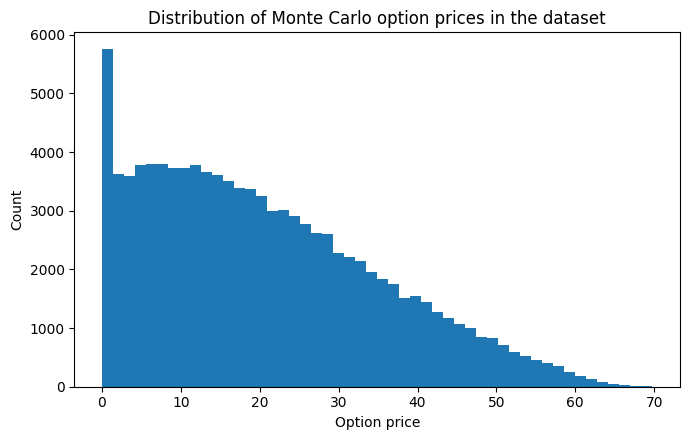

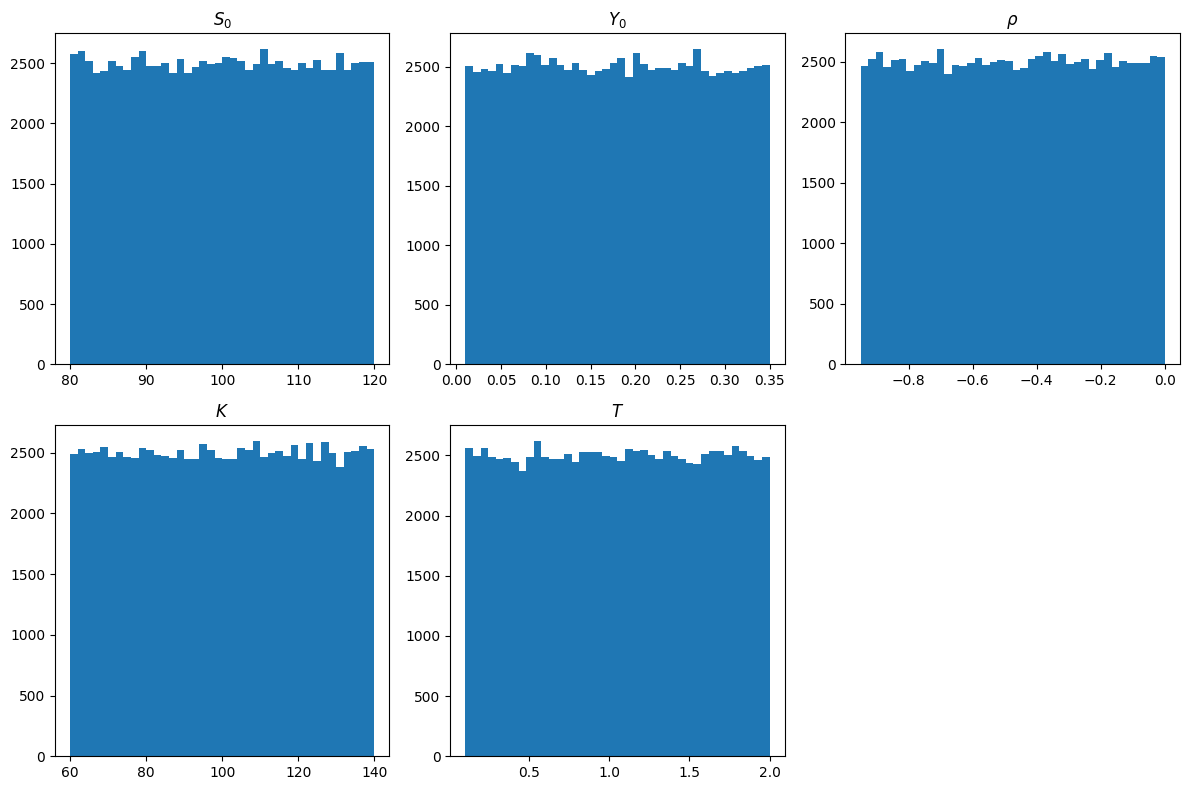

In [17]:
plot_label_distribution(y_train)
plot_feature_histograms(X_train)

In [ ]:
x = torch.tensor([
    [100.0,   # S0
     0.04,    # Y0
     2.0,     # kappa
     0.04,    # mu
     0.3,     # sigma
     0.05,    # r
     -0.7,    # rho
     100.0,   # K
     1.0]     # T
], device=device, dtype=torch.float32)

price = heston_mc_price_batch(
    X=x,
    n_paths=100_000,
    n_steps=200,
    device=device,
    dtype=torch.float32
)
print("Monte Carlo Heston price:", price.item())

price = heston_mc_price_batch_av(
    X=x,
    n_paths=100_000,
    n_steps=200,
    device=device,
    dtype=torch.float32
)

print("Monte Carlo Anthetic Variable Heston price:", price.item())

Monte Carlo Heston price: 10.466689109802246
Monte Carlo Anthetic Variable Heston price: 10.411087036132812
